In [5]:
from transformers import WhisperFeatureExtractor, WhisperProcessor, WhisperForConditionalGeneration, WhisperTokenizer, Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers.models.whisper.english_normalizer import BasicTextNormalizer
from datasets import load_dataset, DatasetDict, Audio, Dataset
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import pandas as pd
import evaluate
import torch
import os


"""
NB: La methode load_dataset de huggingface ne marche plus pour les nouveaux datasets de common voice, Alors on telecharge le dataset
en local, on le convertis en dataframe pandas, puis on le convertit en dataset huggingface et on fait le reechantillonage des datasets 
"""
def load_local_dataset(PATH):
    # Declarer le dataset au format de huggingface (DatasetDict)
    common_voice = DatasetDict()
    
    # chemin absolu vers le datsets 
    directory = "/info/raid-etu/m1/s2506992/projet-m1-asr/datasets"
    #chemin vers le fichier audio
    PATH_TO_AUDIO = "/info/raid-etu/m1/s2506992/projet-m1-asr/datasets/" + PATH + "clips/"

    # Creer les chemins dynamiques
    tsv_path_train = os.path.join(directory, PATH, "train.tsv")
    tsv_path_dev = os.path.join(directory, "..", "datasets", PATH, "dev.tsv")
    tsv_path_test = os.path.join(directory, "..", "datasets", PATH, "test.tsv")

    # Convertir en dataframe oandas
    df_train = pd.read_csv(tsv_path_train, delimiter='\t')
    df_dev = pd.read_csv(tsv_path_dev, delimiter='\t')
    df_test = pd.read_csv(tsv_path_test, delimiter='\t')

    # Convertir en dataset huggingface
    common_voice["train"] = Dataset.from_pandas(df_train)
    common_voice["dev"] = Dataset.from_pandas(df_dev)
    common_voice["test"] = Dataset.from_pandas(df_test)

    # Creer la colonne audio pour les trois corpus, elle contient le chemin complet vers l'audio
    common_voice["train"] = common_voice["train"].map( lambda x: {"audio": PATH_TO_AUDIO + x["path"]})
    common_voice["dev"] = common_voice["dev"].map( lambda x: {"audio": PATH_TO_AUDIO + x["path"]})
    common_voice["test"] = common_voice["test"].map( lambda x: {"audio": PATH_TO_AUDIO + x["path"]})

    # On fait le Reechantillonnage des fichiers audio en 16000khz (les audios de common voice sont en 48000khz par defaut) 
    common_voice["train"] = common_voice["train"].cast_column("audio", Audio(sampling_rate=16_000))
    common_voice["dev"] = common_voice["dev"].cast_column("audio", Audio(sampling_rate=16_000))
    common_voice["test"] = common_voice["test"].cast_column("audio", Audio(sampling_rate=16_000))
    
    return common_voice

"""
cette methode sert a eliminer tout les colonnes non necessaires pour l'apprentissage, on garde une nouvelle colonne: inputfeatures; elle contient un tableau
numpy qui represente les caracteres acoustiques de l'audio, et une colonne label; elle contient la label dans le format Token
"""
def prepare_dataset(batch, feature_extractor, tokenizer):
    # recuperer les colonnes 'audio'
    audio = batch["audio"]

    # on cree une nouvelle colonne 'input_features' qui contiendra les tableaux numpy qui represente le fichier audio 
    batch["input_features"] = feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]

    # on transforme le text en token numerique
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    
    return batch


"""
Un Data Collator sert a preparer le bacth avant de l'envoyer au model, dans notre cas il va servir pour faire 3 choses:
- etape 1: on transforme la colonne 'input features' qui contient les tableaux numpy en tensor pytorch
- etape 2: on unifie la taille des tokens numerique (qui represente les labels) en ajoutant des <pad> qui seront apres remplace par des -100 pour ne pas biaiser 
  les metrics d'evaluation
- etape 3: on supprime le token <s> qui indique le debut de sequence
"""

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # etape 1: 
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        # etape 2
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # etape 3
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels

        return batch
        
# Charger la  metric
metric = evaluate.load("wer")

# Defintion des Hyperparametre de l'entrainement
training_args = Seq2SeqTrainingArguments(
    output_dir=os.path.join("..", "results","whisperBaseTurc"),  # repertoire enregistrement des chekcpoints
    do_train=True,                      
    do_eval=True,  
    per_device_train_batch_size=4,        # petit batch par GPU
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,        # pour batch effectif ~32
    learning_rate=1e-5,
    warmup_steps=50,                      # petit warmup, dataset petit
    max_steps=500,                        # limite les epochs pour <8h
    gradient_checkpointing=False,         # économise la mémoire
    fp16=True,                            # demi-précision
    eval_strategy="steps",
    eval_steps=50,
    save_steps=50,
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    predict_with_generate=True,           # pour WER
)

def whisper_finetune (PATH):
    
    processor = WhisperProcessor.from_pretrained("openai/whisper-small",language="turkish", task="transcribe")

    feature_extractor = processor.feature_extractor

    tokenizer = WhisperTokenizer.from_pretrained("openai/whisper-small", language="turkish", task="transcribe")

    model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

    # on recupere le dataset
    common_voice = load_local_dataset(PATH)
    
    # le dataset avec deux colonnes, input_features: spectogramme mel et labels: les tokens numerique des etiquetes
    common_voice = common_voice.map(prepare_dataset, remove_columns=common_voice.column_names["train"], fn_kwargs={"feature_extractor": feature_extractor,  "tokenizer": tokenizer})

    # Initialiser le datacollator
    data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
    )

    """
    elle prends les predictions, elle les compare les predictions et les labels, et retourne la word_error_rate
    """
    def compute_metrics(pred):

        normalizer = BasicTextNormalizer()
    
        # on recupere les predictions
        pred_ids = pred.predictions
    
        # on recupere les labels 
        label_ids = pred.label_ids

        # replace -100 with the pad_token_id
        label_ids[label_ids == -100] = tokenizer.pad_token_id

        # on decode (on convertit les tokens numerique en text) les deux, pred_ids et label_ids
        pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
        label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

        pred_str = [normalizer(s) for s in pred_str]
        label_str = [normalizer(s) for s in label_str]

        # calcul du taux d'erreur
        wer = 100 * metric.compute(predictions=pred_str, references=label_str)

        return {"wer": wer}

    # Initialiser le trainer
    trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=common_voice["train"],
    eval_dataset=common_voice["dev"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    )
    
    # lancer l'entrainement
    trainer.train()
    
if __name__ == "__main__":
    PATH = 'zazaki/'
    whisper_finetune(PATH)
    


Map: 100%|██████████| 392/392 [00:04<00:00, 92.57 examples/s] 
/tmp/ipykernel_747641/2143132134.py:176: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,Wer
50,0.941600,1.518218,77.290323
100,0.172900,1.626297,72.946237
150,0.033200,1.860712,73.075269
200,0.007400,2.112166,73.333333
250,0.004400,2.198915,72.129032
300,0.002000,2.287546,73.376344
350,0.001500,2.298269,73.161290
400,0.001300,2.311947,73.376344
450,0.001200,2.321921,73.333333
500,0.001100,2.325701,73.419355


/info/etu/m1/s2506992/miniconda3/envs/asr2526_new/lib/python3.10/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


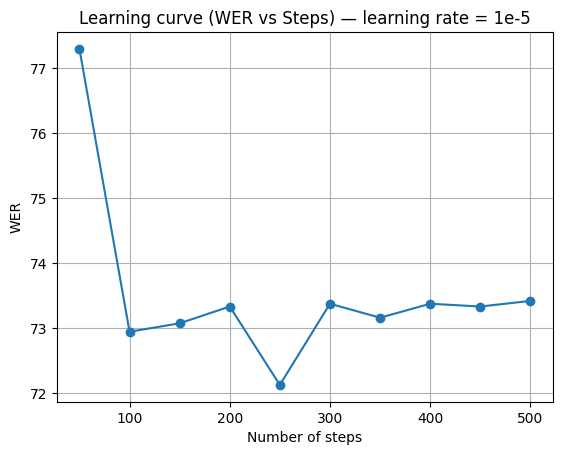

In [1]:
import matplotlib.pyplot as plt

# Data from the table
steps = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
wer = [77.290323, 72.946237, 73.075269, 73.333333, 72.129032,
       73.376344, 73.161290, 73.376344, 73.333333, 73.419355]

# Plot
plt.figure()
plt.plot(steps, wer, marker='o')
plt.xlabel("Number of steps")
plt.ylabel("WER")
plt.title("Learning curve (WER vs Steps) — learning rate = 1e-5")
plt.grid(True)
plt.show()


In [4]:
!pip install matplotlib